# PCA and clustering

Inputs: data/clean.parquet (reviewed listings only)

Outputs:
- outputs/evidence_cluster.json (numbers cited in the report)
- outputs/pca_table.csv
- outputs/cluster_profiles.csv
- outputs/fig_pca_clusters.png (report Figure 3)
- outputs/fig_elbow.png
- outputs/fig_dendrogram.png


### Section 0: Setup


In [2]:
import json
import pathlib

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Constants:
PROJECT_ROOT = pathlib.Path().resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR = PROJECT_ROOT / "data"
DEFAULT_ROUNDING_DECIMALS = 4
RANDOM_SEED = 20008
N_CLUSTERS_RANGE = range(2, 9)
FIGURE_SAMPLE_SIZE = 5000
DENDROGRAM_SAMPLE_SIZE = 2000


# Utility function used to round a value to a given number of places
def round_value(value, digits=DEFAULT_ROUNDING_DECIMALS):
    return round(float(value), digits)


evidence = {}

# Listings dataframe
listings = pd.read_parquet(DATA_DIR / "clean.parquet")

### Section 1: Data


In [4]:
# Clustering covers reviewed listings only. The 4,477 zero-review listings all share the
# artificial fill value 4,594 for days_since_last_review, so they would collapse into a
# fake cluster that describes the imputation rather than the listings.
listings_reviewed = listings[listings["has_review"] == 1].copy()

evidence["n_rows_full"] = len(listings)
evidence["n_hosts_full"] = listings["host_id"].nunique()
evidence["superhost_rate_full"] = round_value(listings["y"].mean())
evidence["n_rows_reviewed"] = len(listings_reviewed)
evidence["n_hosts_reviewed"] = listings_reviewed["host_id"].nunique()
evidence["superhost_rate_reviewed"] = round_value(listings_reviewed["y"].mean())

### Section 2: Feature sets


In [6]:
# Three candidate feature sets. S3 is used: only a set holding both families lets the PCA
# loadings and cluster centres show which family the data's main structure runs along.
FUNDAMENTAL_FEATURES = ["dist_cbd", "accommodates"]
OPERATIONAL_FEATURES = ["availability_365", "amenity_count", "days_since_last_review", "host_listings_count"]
CANDIDATE_FEATURE_SETS = {
    "S1_operational_only": OPERATIONAL_FEATURES,
    "S2_fundamentals_only": FUNDAMENTAL_FEATURES,
    "S3_mixed": FUNDAMENTAL_FEATURES + OPERATIONAL_FEATURES,
}
CLUSTER_FEATURES = CANDIDATE_FEATURE_SETS["S3_mixed"]
LOG_FEATURES = ["days_since_last_review", "host_listings_count", "dist_cbd"]
CLUSTER_GUARDS = FUNDAMENTAL_FEATURES + OPERATIONAL_FEATURES

clustering_input = listings_reviewed[CLUSTER_FEATURES].copy()

# Evidence for the feature-set choice and for the exclusions
evidence["candidate_feature_sets"] = {name: columns for name, columns in CANDIDATE_FEATURE_SETS.items()}
evidence["skew_before_log"] = {column: round_value(clustering_input[column].skew(), 2) for column in CLUSTER_FEATURES}
evidence["max_before_log"] = {column: round_value(clustering_input[column].max(), 2) for column in CLUSTER_FEATURES}
evidence["price_missing_reviewed_pct"] = round_value(listings_reviewed["price_num"].isna().mean() * 100, 2)
evidence["price_skew_reviewed"] = round_value(listings_reviewed["price_num"].skew(), 2)
evidence["price_max_reviewed"] = round_value(listings_reviewed["price_num"].max(), 2)
evidence["minimum_nights_le3_pct"] = round_value((listings_reviewed["minimum_nights"] <= 3).mean() * 100, 2)
evidence["minimum_nights_skew"] = round_value(listings_reviewed["minimum_nights"].skew(), 2)

### Section 3: Preprocessing


In [ ]:
# Log transform the three skewed features: PCA and K-Means are driven by variance and
# distance, so a single maximum of 667 listings would dominate the first component.
# log1p rather than log: days_since_last_review reaches 0.
log_transformed = clustering_input.copy()
for column in LOG_FEATURES:
    log_transformed[column] = np.log1p(log_transformed[column])

# Standardise all features, availability_365 (0-365) > accommodates (1-16)
scaler = StandardScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(log_transformed),
    columns=CLUSTER_FEATURES,
    index=log_transformed.index,
)

# Every column should be centred and unit-scaled
evidence["scaled_mean_abs_max"] = round_value(scaled_features.mean().abs().max(), 6)
evidence["scaled_std_min"] = round_value(scaled_features.std(ddof=0).min())

### Section 4: PCA


In [10]:
pca = PCA()
principal_components = pca.fit_transform(scaled_features)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

evidence["n_components"] = int(len(explained_variance))
evidence["explained_variance_first3"] = [round_value(value) for value in explained_variance[:3]]
evidence["cumulative_variance_first3"] = [round_value(value) for value in cumulative_variance[:3]]

# For each of the first three components, the three features with the largest loadings
# by absolute value. The signs are kept: a component can be flipped as a whole, so what
# matters is which features share a sign and which oppose.
pca_rows = []
for component_index in range(3):
    loadings = pd.Series(pca.components_[component_index], index=CLUSTER_FEATURES)
    top_loadings = loadings.reindex(loadings.abs().sort_values(ascending=False).index)[:3]
    row = {
        "component": f"PC{component_index + 1}",
        "explained_variance": round_value(explained_variance[component_index]),
        "cumulative_variance": round_value(cumulative_variance[component_index]),
    }
    for rank, (feature, value) in enumerate(top_loadings.items(), start=1):
        row[f"loading_{rank}_feature"] = feature
        row[f"loading_{rank}_value"] = round_value(value, 3)
    pca_rows.append(row)
pca_table = pd.DataFrame(pca_rows)

evidence["pca_top_loadings"] = {row["component"]: [[row[f"loading_{rank}_feature"], row[f"loading_{rank}_value"]] for rank in (1, 2, 3)] for row in pca_rows}

pca_table

  component  explained_variance  ...  loading_3_feature loading_3_value
0       PC1              0.3211  ...   availability_365          -0.447
1       PC2              0.2045  ...       accommodates           0.208
2       PC3              0.1681  ...      amenity_count           0.355

[3 rows x 9 columns]

### Section 5: K-Means


Chosen k= 5


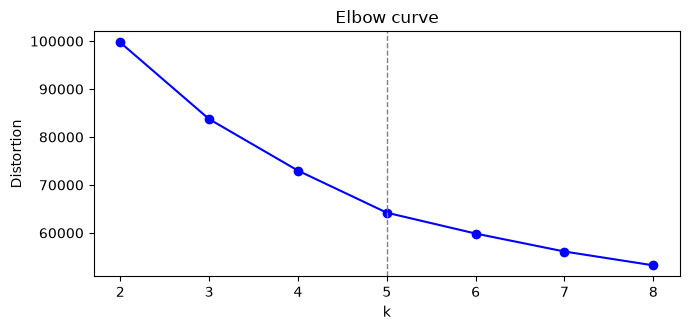

In [61]:
# Fit K-Means once per candidate k.
# distortion = the sum of squared distances from each listing to its own
# cluster centre.
distortions = []
for k in N_CLUSTERS_RANGE:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
    kmeans.fit(scaled_features)
    distortions.append(kmeans.inertia_)

kmeans_sweep = pd.DataFrame({"k": list(N_CLUSTERS_RANGE), "distortion": distortions})
evidence["kmeans_sweep"] = kmeans_sweep.round(DEFAULT_ROUNDING_DECIMALS).to_dict("records")

# k is chosen by eye from the distortion curve below
CHOSEN_K = 5

# Elbow plot
figure, axis = plt.subplots(figsize=(7, 3.4))
axis.plot(kmeans_sweep["k"], kmeans_sweep["distortion"], "bo-")
axis.axvline(CHOSEN_K, color="grey", linestyle="--", linewidth=1)
axis.set(title=f"Elbow curve", xlabel="k", ylabel="Distortion")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_elbow.png", dpi=150)
plt.close(figure)

evidence["chosen_k"] = CHOSEN_K
evidence["chosen_k_distortion"] = round_value(kmeans_sweep.loc[kmeans_sweep["k"] == CHOSEN_K, "distortion"].iloc[0], 1)

kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_SEED)
kmeans_labels = kmeans_final.fit_predict(scaled_features)

evidence["kmeans_sizes"] = {int(k): int(v) for k, v in pd.Series(kmeans_labels).value_counts().sort_index().items()}  # ty:ignore[invalid-argument-type]
print("Chosen k=", CHOSEN_K)
figure

### Section 6: Hierarchical


In [ ]:
# Both methods to use the same k, which is passed in as n_clusters.
# Ward merges the pair of clusters that adds the least within-cluster variance, which is
# the same quantity K-Means minimises.
hierarchical_model = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(scaled_features)

evidence["hierarchical_sizes"] = {int(k): int(v) for k, v in pd.Series(hierarchical_labels).value_counts().sort_index().items()}
evidence["hierarchical_clusters_returned"] = int(pd.Series(hierarchical_labels).nunique())

### Section 7: Comparing the two methods


In [16]:
# Cluster numbering is arbitrary, so the comparison runs through the cross-tabulation
# rather than through the labels themselves. The crosstab and the size columns are the
# evidence: they show which clusters correspond one-to-one and which are split.
cluster_crosstab = pd.crosstab(
    pd.Series(kmeans_labels, name="kmeans_cluster"),
    pd.Series(hierarchical_labels, name="hierarchical_cluster"),
)

evidence["kmeans_vs_hierarchical_sizes"] = {
    "kmeans": evidence["kmeans_sizes"],
    "hierarchical": evidence["hierarchical_sizes"],
}
# orient="index" gives {kmeans cluster: {hierarchical cluster: count}}, matching the
# printed table. The default orient is dict-of-columns, which nests it the other way up.
evidence["crosstab"] = {str(k): {str(k2): int(v) for k2, v in row.items()} for k, row in cluster_crosstab.to_dict(orient="index").items()}

cluster_crosstab

hierarchical_cluster     0     1     2     3     4
kmeans_cluster                                    
0                      119   609  3696     0   117
1                     4410   507   409     2    12
2                      815   549   100  3224     1
3                     1099    54   199     2  1011
4                     1813  2110   312    21    60

### Section 8: Cluster profiles


In [18]:
def build_cluster_profiles(labels, method_name):
    """Median of each clustering feature in original units, plus the superhost rate."""
    frame = listings_reviewed.assign(cluster=labels)
    profiles = frame.groupby("cluster").agg(
        listings=("cluster", "size"),
        superhost_rate=("y", "mean"),
        **{column: (column, "median") for column in CLUSTER_FEATURES},
    )
    profiles.insert(0, "method", method_name)
    profiles.insert(2, "share", profiles["listings"] / len(frame))
    return profiles.round(DEFAULT_ROUNDING_DECIMALS)


cluster_profiles = pd.concat(
    [
        build_cluster_profiles(kmeans_labels, "KMeans"),
        build_cluster_profiles(hierarchical_labels, "Hierarchical"),
    ]
).reset_index(names="cluster")

# y appears for the first time here, and only to describe the clusters
evidence["cluster_profiles"] = cluster_profiles.to_dict("records")
evidence["kmeans_superhost_rate_spread"] = round_value(cluster_profiles.query("method == 'KMeans'")["superhost_rate"].max() - cluster_profiles.query("method == 'KMeans'")["superhost_rate"].min())
evidence["hierarchical_superhost_rate_spread"] = round_value(
    cluster_profiles.query("method == 'Hierarchical'")["superhost_rate"].max() - cluster_profiles.query("method == 'Hierarchical'")["superhost_rate"].min()
)

cluster_profiles

   cluster        method  ...  days_since_last_review  host_listings_count
0        0        KMeans  ...                    50.0                 50.0
1        1        KMeans  ...                    40.0                  2.0
2        2        KMeans  ...                  1883.0                  1.0
3        3        KMeans  ...                    58.0                  3.0
4        4        KMeans  ...                    76.0                  2.0
5        0  Hierarchical  ...                    56.0                  1.0
6        1  Hierarchical  ...                   100.0                  3.0
7        2  Hierarchical  ...                    55.0                 45.0
8        3  Hierarchical  ...                  2364.0                  1.0
9        4  Hierarchical  ...                    49.0                 12.0

[10 rows x 11 columns]

### Section 9: Figures


In [20]:
# Dendrogram
dendrogram_sample = scaled_features.sample(DENDROGRAM_SAMPLE_SIZE, random_state=RANDOM_SEED)
figure, axis = plt.subplots(figsize=(9, 4.5))
dendrogram(linkage(dendrogram_sample.to_numpy(), method="ward"), truncate_mode="lastp", p=30, ax=axis, no_labels=True)
axis.set(title=f"Ward dendrogram (n={DENDROGRAM_SAMPLE_SIZE}, k={CHOSEN_K})", ylabel="Merge distance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_dendrogram.png", dpi=150)
plt.close(figure)

# PCA Scatterplot
STATUS_COLOURS = {"Non-superhost": "#4C72B0", "Superhost": "#DD8452"}
sample_positions = np.random.default_rng(RANDOM_SEED).choice(len(principal_components), min(FIGURE_SAMPLE_SIZE, len(principal_components)), replace=False)
scatter_frame = pd.DataFrame(
    {
        "PC1": principal_components[sample_positions, 0],
        "PC2": principal_components[sample_positions, 1],
        "Status": np.where(listings_reviewed["y"].to_numpy()[sample_positions] == 1, "Superhost", "Non-superhost"),
    }
)
centres_in_pc_space = pca.transform(pd.DataFrame(kmeans_final.cluster_centers_, columns=CLUSTER_FEATURES))

figure, axis = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(data=scatter_frame, x="PC1", y="PC2", hue="Status", palette=STATUS_COLOURS, s=8, alpha=0.3, linewidth=0, legend=False, ax=axis)
sns.scatterplot(x=centres_in_pc_space[:, 0], y=centres_in_pc_space[:, 1], marker="X", s=90, color="green", ax=axis)
axis.set(
    xlabel=f"1st Principal Component ({explained_variance[0] * 100:.1f}% of variance)",
    ylabel=f"2nd Principal Component ({explained_variance[1] * 100:.1f}% of variance)",
    title=f"PCA of listings coloured by superhost status (n={len(listings_reviewed)})",
)
axis.legend(
    handles=[Patch(color=colour, label=status) for status, colour in STATUS_COLOURS.items()] + [Patch(color="green", label=f"K-Means centroids (k={CHOSEN_K})")],
    loc="upper right",
)
plt.savefig(OUTPUT_DIR / "fig_pca_clusters.png", dpi=150)
plt.close(figure)

figure

<Figure size 750x550 with 1 Axes>

### Section 10: Save


In [22]:
# Checks before saving
assert len(listings_reviewed) == evidence["n_rows_reviewed"]
assert scaled_features.notna().all().all()
assert evidence["n_components"] == len(CLUSTER_FEATURES)
assert evidence["hierarchical_clusters_returned"] == CHOSEN_K
assert len(dendrogram_sample) == DENDROGRAM_SAMPLE_SIZE

pca_table.to_csv(OUTPUT_DIR / "pca_table.csv", index=False)
cluster_profiles.round(DEFAULT_ROUNDING_DECIMALS).to_csv(OUTPUT_DIR / "cluster_profiles.csv", index=False)
with open(OUTPUT_DIR / "evidence_cluster.json", "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=str)

print(f"rows clustered        : {len(scaled_features):,}")
print(f"chosen k              : {CHOSEN_K}")
print(f"PC1 / PC2 variance    : {explained_variance[0] * 100:.1f}% / {explained_variance[1] * 100:.1f}%")

rows clustered        : 21,251
chosen k              : 5
PC1 / PC2 variance    : 32.1% / 20.4%
